In [129]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction import FeatureHasher
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("data.csv")

print("First 5 strings:")
display(df.head(10))

print("\nLast 5 strings:")
display(df.tail(10))

print("\nSize of a table:")
print(df.shape)

print("\nInfo:")
df.info()

print("\nOverall info about number columns:")
display(df.describe())

print("\nInfo about columns:")
display(df.describe(include=["object", "str"]))

print("\nAll blank strings:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nRating:")
print(df["Rating"].min(), df["Rating"].max())

print("\nUniques:")
display(df.nunique())

First 5 strings:


,App,Category,Rating,Reviews,Size_MB,Installs,Type,Price_$,Content_Rating,Genres,Last_Updated,Android_Version
0,PulseGuide,HEALTH,3.7,401077,58.7,"1,000,000+",Paid,1.99,Teen,Education,2024-06-05,8.0 and up
1,StyleMind Pro,LIFESTYLE,5.0,460806,17.3,"10,000+",Free,0.00,Mature 17+,Education,2024-09-14,8.0 and up
2,StarCare Mix,ENTERTAINMENT,2.5,4989914,153.3,"10,000,000+",Free,0.00,Teen,Health,2024-06-12,5.0 and up
3,VoltRush Go,TOOLS,3.0,1004011,21.1,"1,000+",Free,0.00,Everyone,Action,2024-05-26,4.1 and up
4,WellTrack Now,HEALTH,3.5,312033,17.6,"1,000,000+",Free,0.00,Everyone,Health,2024-06-02,4.1 and up
5,ClassPulse Edge,EDUCATION,4.8,3205609,20.7,"1,000+",Free,0.00,Teen,Health,2024-02-07,4.1 and up
6,VitaTrack Go,HEALTH,2.7,4686176,39.9,"10,000+",Free,0.00,Everyone,Music,2024-05-10,6.0 and up
7,VibeSteps Max,ENTERTAINMENT,2.5,3177912,73.2,"10,000+",Paid,4.99,Mature 17+,Health,2024-12-23,6.0 and up
8,CoreScan,TOOLS,2.6,755121,27.5,"10,000,000+",Free,0.00,Mature 17+,Tools,2024-09-11,8.0 and up
9,DailyGuard Now,LIFESTYLE,2.7,2320725,25.4,"10,000,000+",Free,0.00,Teen,Health,2024-07-26,6.0 and up



Last 5 strings:


,App,Category,Rating,Reviews,Size_MB,Installs,Type,Price_$,Content_Rating,Genres,Last_Updated,Android_Version
1190,WellBlast Night,HEALTH,4.1,1465925,90.2,"1,000,000+",Free,0.00,Mature 17+,Action,2024-11-04,6.0 and up
1191,TuneZone Mix,ENTERTAINMENT,3.8,350077,162.2,"1,000,000+",Free,0.00,Teen,Action,2024-05-23,6.0 and up
1192,HeroRaid,GAME,4.6,1706836,159.4,"1,000,000+",Free,0.00,Mature 17+,Action,2024-12-11,5.0 and up
1193,VivaDrive Mix,LIFESTYLE,3.2,2059395,35.5,"10,000+",Free,0.00,Teen,Business,2024-09-17,6.0 and up
1194,MintSound Now,FINANCE,3.6,1441256,86.2,"10,000+",Free,0.00,Everyone,Music,2024-03-13,5.0 and up
1195,DeskBalance Dark,PRODUCTIVITY,3.2,2367332,89.1,"10,000,000+",Free,0.00,Mature 17+,Health,2024-06-22,4.1 and up
1196,LeadPilot Play,BUSINESS,4.5,1375655,28.6,"10,000,000+",Free,0.00,Teen,Business,2024-08-19,8.0 and up
1197,MythGuard Elite,GAME,3.9,3738868,83.1,"1,000+",Paid,1.99,Everyone,Health,2024-09-26,6.0 and up
1198,WorkMaze Prime,BUSINESS,4.1,2270473,65.8,"10,000+",Paid,1.99,Everyone,Puzzle,2024-12-27,4.1 and up
1199,CarePanel,HEALTH,3.1,834450,22.6,"10,000+",Free,0.00,Everyone,Tools,2024-08-09,6.0 and up



Size of a table:
(1200, 12)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   App              1200 non-null   str    
 1   Category         1200 non-null   str    
 2   Rating           1200 non-null   float64
 3   Reviews          1200 non-null   int64  
 4   Size_MB          1200 non-null   float64
 5   Installs         1200 non-null   str    
 6   Type             1200 non-null   str    
 7   Price_$          1200 non-null   float64
 8   Content_Rating   1200 non-null   str    
 9   Genres           1200 non-null   str    
 10  Last_Updated     1200 non-null   str    
 11  Android_Version  1200 non-null   str    
dtypes: float64(3), int64(1), str(8)
memory usage: 112.6 KB

Overall info about number columns:


...

,App,Category,Installs,Type,Content_Rating,Genres,Last_Updated,Android_Version
count,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,9,5,2,3,7,349,4
top,PulseGuide,GAME,"1,000,000+",Free,Everyone,Action,2024-08-08,8.0 and up
freq,1,158,260,1017,415,209,9,333



All blank strings:


App                0
Category           0
Rating             0
Reviews            0
Size_MB            0
Installs           0
Type               0
Price_$            0
Content_Rating     0
Genres             0
Last_Updated       0
Android_Version    0
dtype: int64


Duplicates:
0

Rating:
2.5 5.0

Uniques:


App                1200
Category              9
Rating               26
Reviews            1199
Size_MB             718
Installs              5
Type                  2
Price_$               5
Content_Rating        3
Genres                7
Last_Updated        349
Android_Version       4
dtype: int64

### Preliminary note

The dataset appears doesn't contain any missing values, blank strings, or duplicate rows
Therefore, the data cleaning step related to `dropna()` and `fillna()` is not shown in practice for this dataset.

The following section presents descriptive and extended statistics for the selected columns.

In [130]:
# --------- useful constants ---------

numeric_cols = ["Rating", "Reviews", "Size_MB", "Price_$"]


# --------- Modes, medians, means ---------

print("\n> Modes, means and medians of number categories:")

mmms = pd.DataFrame({
    "Column": numeric_cols,
    "Mode": [
        df["Rating"].mode()[0],
        int(df["Reviews"].mode()[0]),
        df["Size_MB"].mode()[0],
        df["Price_$"].mode()[0]
    ],
    "Median": [
        df["Rating"].median(),
        int(df["Reviews"].median()),
        df["Size_MB"].median(),
        df["Price_$"].median()
    ],
    "Mean": [
        df["Rating"].mean(),
        int(df["Reviews"].mean()),
        df["Size_MB"].mean(),
        df["Price_$"].mean()
    ]
})

mmms["Mean"] = mmms["Mean"].map(lambda x: f"{x:.2f}")
display(summary1)


# --------- percentile ---------

print("\n> Percentile in each number column:")

quantiles = df[numeric_cols].quantile([0.05, 0.25, 0.50, 0.75, 0.95])
display(quantiles)


# --------- advanced statistics ---------

print("\n> Advanced statistics:")

advanced_stats = pd.DataFrame({
    "Variance": df[numeric_cols].var(),
    "Skewness": df[numeric_cols].skew(),
    "Kurtosis": df[numeric_cols].kurt()
})
advanced_stats["Variance"] = advanced_stats["Variance"].map(lambda x: f"{x:.2f}")
display(advanced_stats)

# --------- the most frequent values ---------

print("\n> The most frequent value in certain columns:")

frequency = pd.DataFrame({
    "Column": ["Frequency"],
    "Category": [df["Category"].mode()[0]],
    "Installs": [df["Installs"].mode()[0]],
    "Type": [df["Type"].mode()[0]],
    "Price_$": [df["Price_$"].mode()[0]],
    "Content_Rating": [df["Content_Rating"].mode()[0]],
    "Genres": [df["Genres"].mode()[0]],
    "Android_Version": [df["Android_Version"].mode()[0]]
})

display(frequency)



> Modes, means and medians of number categories:


,Column,Mode,Median,Mean
0,Rating,4.00,3.70,3.74
1,Reviews,3205238.00,2467298.00,2494315.00
2,Size_MB,2.50,2.50,2.50
3,Price_$,0.99,1.99,2.15



> Percentile in each number column:


,Rating,Reviews,Size_MB,Price_$
0.05,2.6,263321.45,15.495,0.00
0.25,3.1,1280934.50,27.000,0.00
0.50,3.7,2467298.50,43.600,0.00
0.75,4.4,3766748.25,76.925,0.00
0.95,4.9,4754920.45,204.340,2.99



> Advanced statistics:


,Variance,Skewness,Kurtosis
Rating,0.53,0.006913,-1.195152
Reviews,2113536970662.93,0.030865,-1.212194
Size_MB,4113.62,2.316289,5.880683
Price_$,1.10,3.367311,10.820494



> The most frequent value in certain columns:


,Column,Category,Installs,Type,Price_$,Content_Rating,Genres,Android_Version
0,Frequency,GAME,"1,000,000+",Free,0.0,Everyone,Action,8.0 and up


In [131]:
# --------- useful constants ---------

categorical_cols = ["Category", "Type", "Content_Rating", "Genres"]
high_cardinality_cols = ["App"]


# --------- dataframe before encoding ---------

print("\n> Dataframe before encoding:")

display(df[["App", "Category", "Type", "Content_Rating", "Genres"]].head())


# --------- one-hot encoding ---------

print("\n> One-hot encoding of categorical columns:")

df_ohe = pd.get_dummies(df,columns=categorical_cols,dtype=int)
display(df_ohe.head())


# --------- label encoding (manual binary encoding) ---------

print("\n> Label encoding for column 'Type':")

df_label = df.copy()
df_label["Type_Label"] = df_label["Type"].map({
    "Free": 0,
    "Paid": 1
})

display(df_label[["Type", "Type_Label"]].head())


# --------- target encoding ---------

print("\n> Target encoding for column 'Category' based on 'Rating':")

df_target = df.copy()

df_target["Category_Target_Enc"] = df_target.groupby("Category")["Rating"].transform("mean")

display(df_target[["Category", "Rating", "Category_Target_Enc"]].head())


# --------- feature hashing ---------

print("\n> Feature hashing for high-cardinality column 'App':")

fh = FeatureHasher(n_features=8, input_type="string")

hashed_matrix = fh.transform(
    df["App"].astype(str).apply(lambda x: [x])
)

hashed_df = pd.DataFrame(
    hashed_matrix.toarray(),
    columns=[f"App_Hash_{i}" for i in range(8)],
    index=df.index
)

display(df[["App"]].head())
display(hashed_df.head())


# --------- feature engineering: month from date ---------

print("\n> New feature: month extracted from 'Last_Updated':")

df_features = df.copy()

df_features["Last_Updated"] = pd.to_datetime(df_features["Last_Updated"], errors="coerce")
df_features["Update_Month"] = df_features["Last_Updated"].dt.month

display(df_features[["Last_Updated", "Update_Month"]].head())


# --------- feature engineering: installs cleaning ---------

print("\n> New feature: numeric version of 'Installs':")

df_features["Installs_Clean"] = (
    df_features["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .astype(int)
)

display(df_features[["Installs", "Installs_Clean"]].head())


# --------- feature engineering: reviews per install ---------

print("\n> New feature: reviews per install:")

df_features["Reviews_per_Install"] = (
    df_features["Reviews"] / df_features["Installs_Clean"]
)

display(df_features[["Reviews", "Installs_Clean", "Reviews_per_Install"]].head())


# --------- feature engineering: price per MB ---------

print("\n> New feature: price per MB:")

df_features["Price_per_MB"] = (
    df_features["Price_$"] / df_features["Size_MB"]
)

display(df_features[["Price_$", "Size_MB", "Price_per_MB"]].head())


# --------- feature engineering: rare categories to 'Other' ---------

print("\n> New feature: grouped rare categories into 'Other':")

category_counts = df_features["Category"].value_counts()
rare_categories = category_counts[category_counts < 20].index

df_features["Category_Grouped"] = df_features["Category"].replace(rare_categories, "Other")

display(df_features[["Category", "Category_Grouped"]].head(15))


# --------- dataframe after feature engineering ---------

print("\n> Dataframe after feature engineering:")

display(df_features[[
    "App",
    "Category",
    "Category_Grouped",
    "Type",
    "Last_Updated",
    "Update_Month",
    "Installs_Clean",
    "Reviews",
    "Reviews_per_Install",
    "Price_$",
    "Size_MB",
    "Price_per_MB"
]].head(10))


> Dataframe before encoding:


,App,Category,Type,Content_Rating,Genres
0,PulseGuide,HEALTH,Paid,Teen,Education
1,StyleMind Pro,LIFESTYLE,Free,Mature 17+,Education
2,StarCare Mix,ENTERTAINMENT,Free,Teen,Health
3,VoltRush Go,TOOLS,Free,Everyone,Action
4,WellTrack Now,HEALTH,Free,Everyone,Health



> One-hot encoding of categorical columns:


,App,Rating,Reviews,Size_MB,Installs,Price_$,Last_Updated,Android_Version,Category_BUSINESS,Category_EDUCATION,...,Content_Rating_Everyone,Content_Rating_Mature 17+,Content_Rating_Teen,Genres_Action,Genres_Business,Genres_Education,Genres_Health,Genres_Music,Genres_Puzzle,Genres_Tools
0,PulseGuide,3.7,401077,58.7,"1,000,000+",1.99,2024-06-05,8.0 and up,0,0,...,0,0,1,0,0,1,0,0,0,0
1,StyleMind Pro,5.0,460806,17.3,"10,000+",0.00,2024-09-14,8.0 and up,0,0,...,0,1,0,0,0,1,0,0,0,0
2,StarCare Mix,2.5,4989914,153.3,"10,000,000+",0.00,2024-06-12,5.0 and up,0,0,...,0,0,1,0,0,0,1,0,0,0
3,VoltRush Go,3.0,1004011,21.1,"1,000+",0.00,2024-05-26,4.1 and up,0,0,...,1,0,0,1,0,0,0,0,0,0
4,WellTrack Now,3.5,312033,17.6,"1,000,000+",0.00,2024-06-02,4.1 and up,0,0,...,1,0,0,0,0,0,1,0,0,0



> Label encoding for column 'Type':


...

,Price_$,Size_MB,Price_per_MB
0,1.99,58.7,0.033901
1,0.00,17.3,0.000000
2,0.00,153.3,0.000000
3,0.00,21.1,0.000000
4,0.00,17.6,0.000000



> New feature: grouped rare categories into 'Other':


,Category,Category_Grouped
0,HEALTH,HEALTH
1,LIFESTYLE,LIFESTYLE
2,ENTERTAINMENT,ENTERTAINMENT
3,TOOLS,TOOLS
4,HEALTH,HEALTH
5,EDUCATION,EDUCATION
6,HEALTH,HEALTH
7,ENTERTAINMENT,ENTERTAINMENT
8,TOOLS,TOOLS
9,LIFESTYLE,LIFESTYLE



> Dataframe after feature engineering:


,App,Category,Category_Grouped,Type,Last_Updated,Update_Month,Installs_Clean,Reviews,Reviews_per_Install,Price_$,Size_MB,Price_per_MB
0,PulseGuide,HEALTH,HEALTH,Paid,2024-06-05,6,1000000,401077,0.401077,1.99,58.7,0.033901
1,StyleMind Pro,LIFESTYLE,LIFESTYLE,Free,2024-09-14,9,10000,460806,46.080600,0.00,17.3,0.000000
2,StarCare Mix,ENTERTAINMENT,ENTERTAINMENT,Free,2024-06-12,6,10000000,4989914,0.498991,0.00,153.3,0.000000
3,VoltRush Go,TOOLS,TOOLS,Free,2024-05-26,5,1000,1004011,1004.011000,0.00,21.1,0.000000
4,WellTrack Now,HEALTH,HEALTH,Free,2024-06-02,6,1000000,312033,0.312033,0.00,17.6,0.000000
5,ClassPulse Edge,EDUCATION,EDUCATION,Free,2024-02-07,2,1000,3205609,3205.609000,0.00,20.7,0.000000
6,VitaTrack Go,HEALTH,HEALTH,Free,2024-05-10,5,10000,4686176,468.617600,0.00,39.9,0.000000
7,VibeSteps Max,ENTERTAINMENT,ENTERTAINMENT,Paid,2024-12-23,12,10000,3177912,317.791200,4.99,73.2,0.068169
8,CoreScan,TOOLS,TOOLS,Free,2024-09-11,9,10000000,755121,0.075512,0.00,27.5,0.000000
9,DailyGuard Now,LIFESTYLE,LIFESTYLE,Free,2024-07-26,7,10000000,2320725,0.232072,0.00,25.4,0.000000



> Histograms with matplotlib:


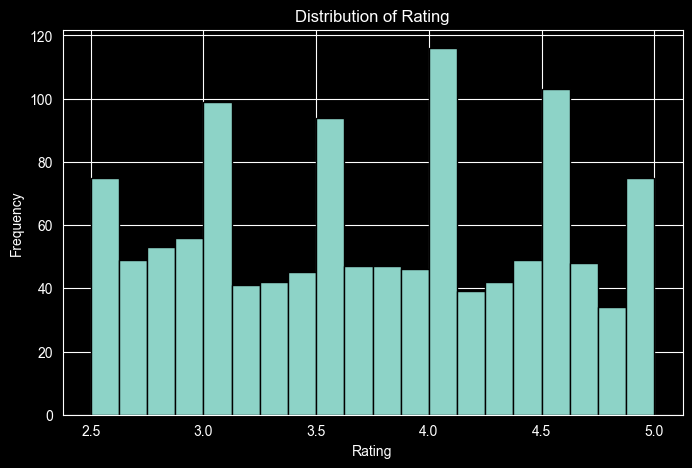

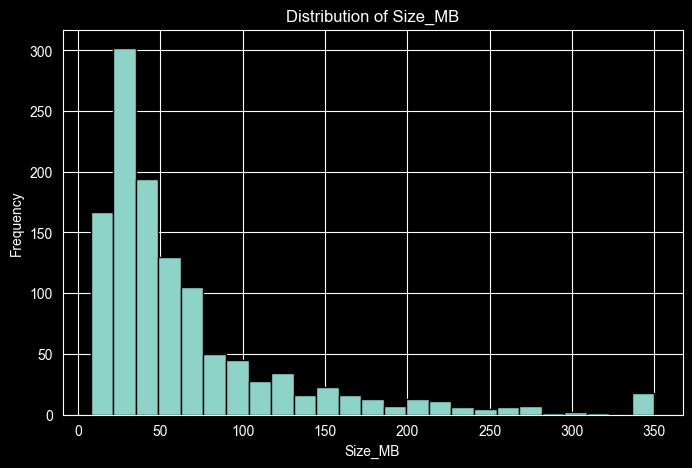


> KDE plots with seaborn:


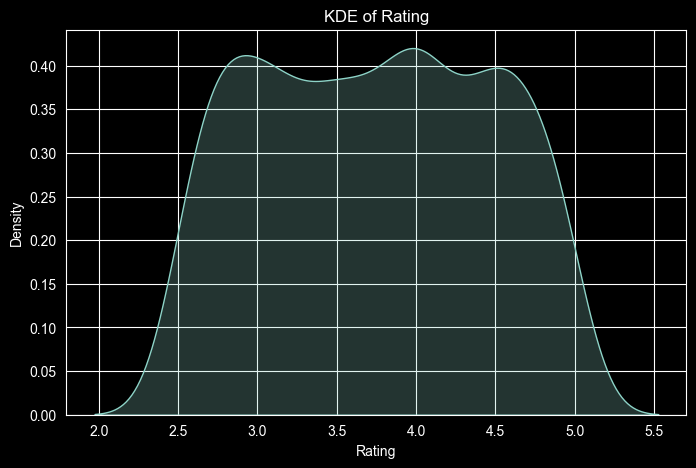

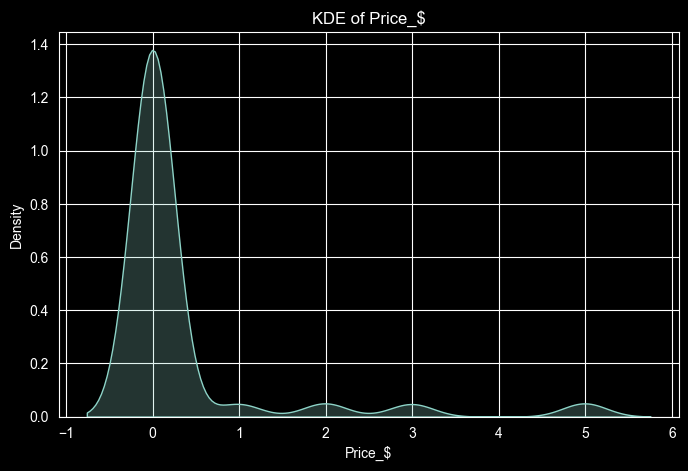


> Scatter plot with seaborn:


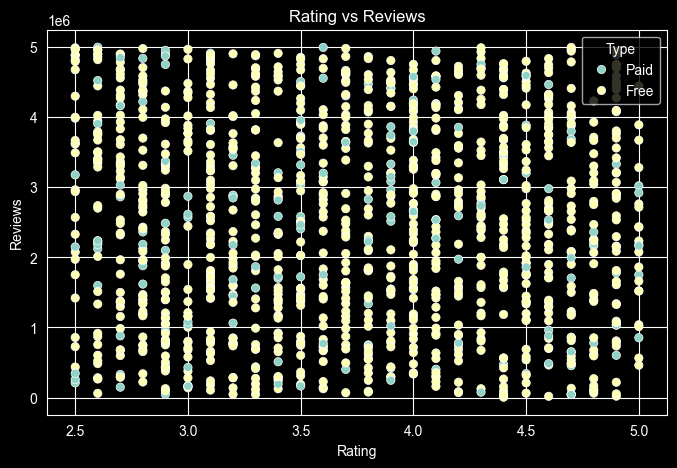


> Interactive scatter plot with plotly:



> Box plots with seaborn:


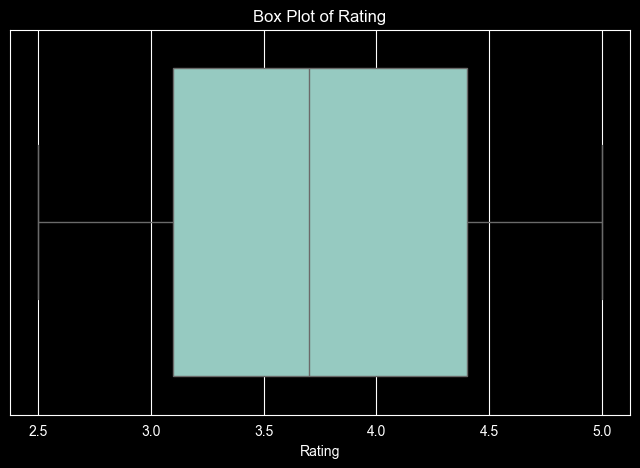

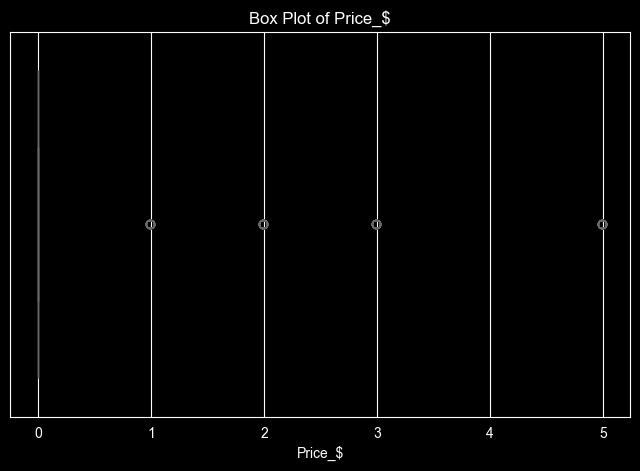

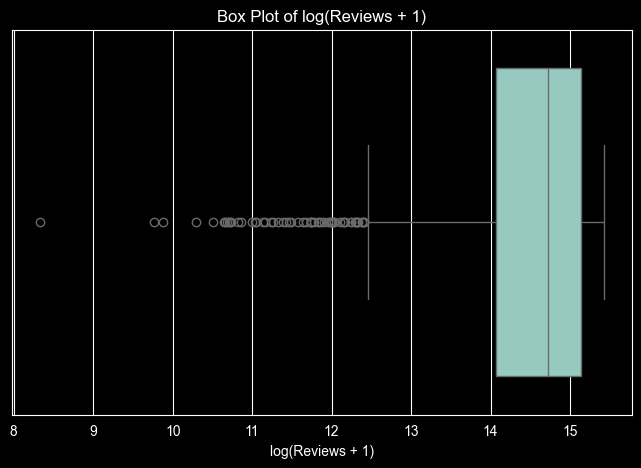


> Count plots for categorical columns:


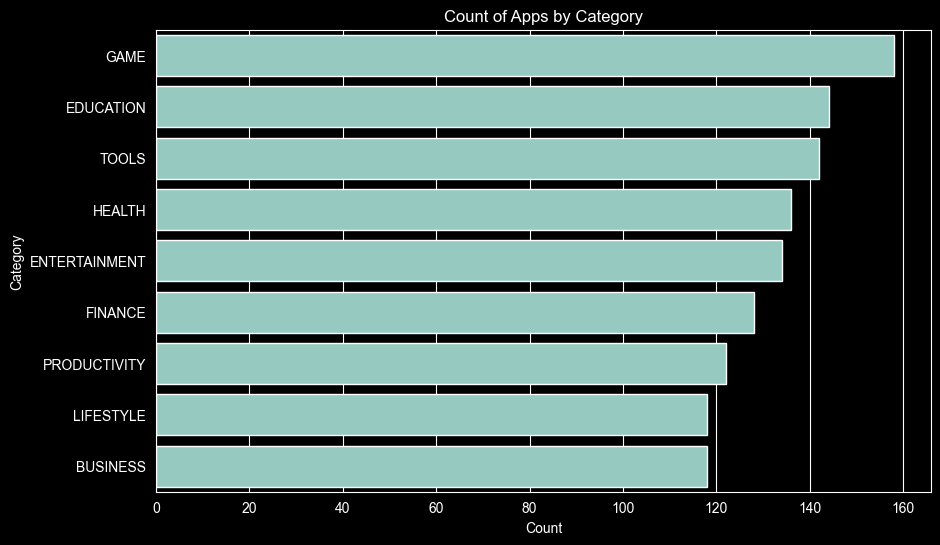

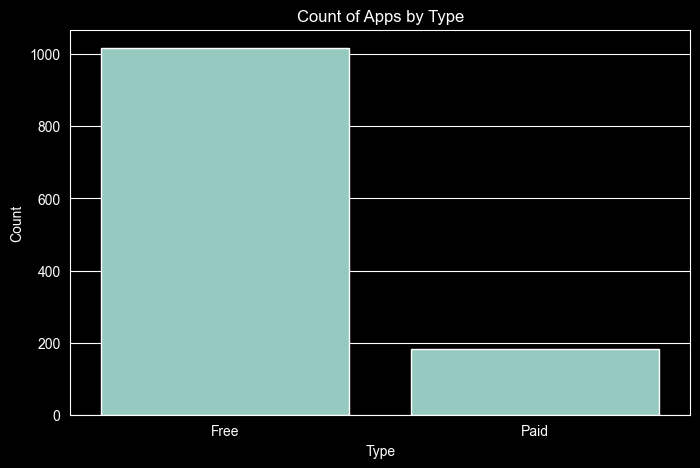


> Correlation heatmap:


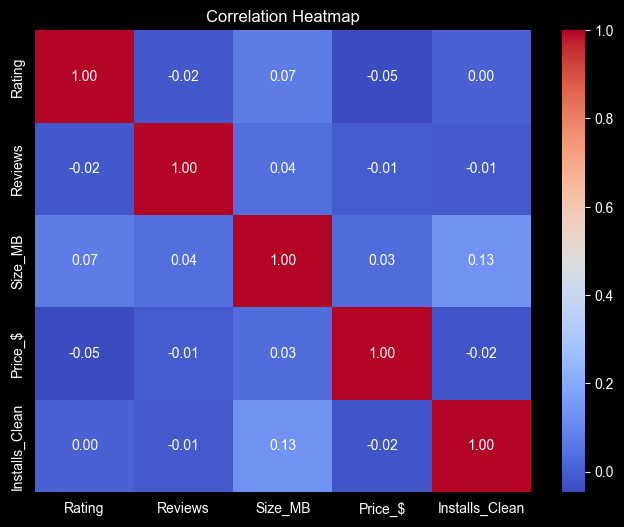

In [132]:
# --------- useful constants ---------

numeric_vis_cols = ["Rating", "Reviews", "Size_MB", "Price_$", "Installs_Clean"]


# --------- matplotlib: histograms ---------

print("\n> Histograms with matplotlib:")

plt.figure(figsize=(8, 5))
plt.hist(df["Rating"], bins=20, edgecolor="black")
plt.title("Distribution of Rating")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["Size_MB"], bins=25, edgecolor="black")
plt.title("Distribution of Size_MB")
plt.xlabel("Size_MB")
plt.ylabel("Frequency")
plt.show()


# --------- seaborn: KDE plots ---------

print("\n> KDE plots with seaborn:")

plt.figure(figsize=(8, 5))
sns.kdeplot(df["Rating"], fill=True)
plt.title("KDE of Rating")
plt.xlabel("Rating")
plt.show()

plt.figure(figsize=(8, 5))
sns.kdeplot(df["Price_$"], fill=True)
plt.title("KDE of Price_$")
plt.xlabel("Price_$")
plt.show()


# --------- seaborn: scatter plot ---------

print("\n> Scatter plot with seaborn:")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Rating", y="Reviews", hue="Type")
plt.title("Rating vs Reviews")
plt.xlabel("Rating")
plt.ylabel("Reviews")
plt.show()


# --------- plotly: interactive scatter ---------

print("\n> Interactive scatter plot with plotly:")

fig = px.scatter(
    df_features,
    x="Installs_Clean",
    y="Reviews",
    color="Type",
    size="Size_MB",
    hover_data=["App", "Category", "Price_$", "Rating"],
    title="Installs vs Reviews"
)

fig.show()


# --------- seaborn: box plots ---------

print("\n> Box plots with seaborn:")

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Rating"])
plt.title("Box Plot of Rating")
plt.xlabel("Rating")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=df["Price_$"])
plt.title("Box Plot of Price_$")
plt.xlabel("Price_$")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x=np.log1p(df["Reviews"]))
plt.title("Box Plot of log(Reviews + 1)")
plt.xlabel("log(Reviews + 1)")
plt.show()


# --------- seaborn: count plots ---------

print("\n> Count plots for categorical columns:")

plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="Category", order=df["Category"].value_counts().index)
plt.title("Count of Apps by Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Type", order=df["Type"].value_counts().index)
plt.title("Count of Apps by Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


# --------- seaborn: correlation heatmap ---------

print("\n> Correlation heatmap:")

corr_matrix = df_features[numeric_vis_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Final conclusions

## What I understood about the dataset

- The dataset is relatively clean: no missing values or duplicate rows were detected.
- Numeric features such as `Rating`, `Reviews`, `Size_MB`, and `Price_$` differ strongly in scale and distribution.
- The `Rating` column is concentrated in a relatively narrow range, so its variance is much lower than for `Reviews`.
- The `Reviews` column has a strong right-skewed distribution: most apps have a moderate number of reviews, while a small number of apps have extremely large values.
- The `Price_$` column is also right-skewed: low prices are much more common than high prices.
- The `Size_MB` column became more realistic after correction and now shows meaningful variation across app types.
- The strongest practical relationship in the dataset is between `Installs` and `Reviews`: apps with more installs usually have more reviews.
- Free apps dominate the dataset more often than paid apps.
- Some categories appear much more frequently than others, which means the dataset is imbalanced in terms of categorical distribution.
- The categorical columns such as `Category`, `Type`, `Content_Rating`, and `Genres` required encoding before they could be used in machine learning models.
- One-hot encoding is the safest approach for nominal categories, while binary encoding is appropriate for the `Type` column.
- New engineered features such as `Installs_Clean`, `Reviews_per_Install`, `Update_Month`, and grouped rare categories can make the dataset more informative for further modeling.

## Hypotheses and observations

- Apps with a larger number of installs tend to receive more reviews, so `Installs` is likely one of the strongest predictors of popularity.
- Paid apps may have different rating and review patterns than free apps, which could indicate a relationship between monetization model and user engagement.
- Extreme values in `Reviews` are likely caused by a small number of very popular apps rather than data errors.
- Higher prices do not necessarily imply higher ratings, so user satisfaction may depend more on app quality and category than on price.
- Some app categories may systematically differ in rating, size, or review count, which suggests that `Category` can have a meaningful influence on the target variable.